In [1]:
%load_ext autoreload
%autoreload 2

import torch

In [2]:
from tqdm.notebook import tqdm_notebook as tqdm
import time

total_epochs = 100
epoch_bar = tqdm(range(total_epochs), desc="Epochs")

for i in epoch_bar:
    time.sleep(0.01)

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

### Preprocess Data

In [ ]:
from preprocess_data import preprocess_data
from pathlib import Path

src_folder = Path("Results_large/")
target_folder = Path("dataset/beam_large/")
print("Preprocessing training data...")
preprocess_data(
    data_dir=src_folder,
    split="train",
    noise_scale=0.0003,
    recalc_velocities=True,
    target_dir=target_folder,
)

print()
print("Preprocessing test data...")
preprocess_data(
    data_dir=src_folder, split="val", recalc_velocities=True, target_dir=target_folder
)

Preprocessing training data...
Processing trajectory: 0
Length of trajectory 0: 49
Processing trajectory: 1
Length of trajectory 1: 49
Processing trajectory: 2
Length of trajectory 2: 49
Processing trajectory: 3
Length of trajectory 3: 49
Processing trajectory: 4
Length of trajectory 4: 49
Processing trajectory: 5
Length of trajectory 5: 49
Processing trajectory: 6
Length of trajectory 6: 49
Processing trajectory: 7
Length of trajectory 7: 49
Processing trajectory: 8
Length of trajectory 8: 49
Processing trajectory: 9
Length of trajectory 9: 49
Processing trajectory: 10
Length of trajectory 10: 49
Processing trajectory: 11
Length of trajectory 11: 49
Processing trajectory: 12
Length of trajectory 12: 49
Processing trajectory: 13
Length of trajectory 13: 49
Processing trajectory: 14
Length of trajectory 14: 49
Processing trajectory: 15
Length of trajectory 15: 49
Processing trajectory: 16
Length of trajectory 16: 49
Processing trajectory: 17
Length of trajectory 17: 49
Processing trajec

### Load Dataset

In [ ]:
from in_memory_dataset import InMemoryTimeStepDataset
from torch_geometric.loader import DataLoader

target_folder = Path("dataset/beam_large/")
train_dataset = InMemoryTimeStepDataset(sample_dir=target_folder / "train")
test_dataset = InMemoryTimeStepDataset(sample_dir=target_folder / "val")

batch_size = 16
num_workers = 4
train_dataloader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers
)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

Found 216 sample files
Loaded the dataset with 10584 samples
Found 1 sample files
Loaded the dataset with 49 samples


### Initialize Model

In [6]:
from models.vinay_mgn import MeshGraphNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

node_channels = 13
edge_channels = 8
num_messages = 8
latent_dim = 128

torch.manual_seed(42)
model = MeshGraphNet(
    node_channels=node_channels,
    edge_channels=edge_channels,
    latent_size=latent_dim,
    num_msgs=num_messages,
)
_ = model.to(device)

### Initialize Trainer

In [7]:
from trainer import Trainer

lr = 5e-5
loss_type = "mse"

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
trainer = Trainer(model, optimizer, device, loss_type=loss_type)
torch.cuda.empty_cache()
print(f"Training_id: {trainer.training_id}")

Training_id: 2026-01-22_10-30-57


### Train Loop

In [8]:
from tqdm.notebook import tqdm_notebook as tqdm
from preprocess_data import Stats
import json

print("Loading stats...")
with open("Results/train/stats/stats.json", "r") as f:
    stats = json.load(f)
node_stats = Stats.from_dict(stats["node"])
edge_stats = Stats.from_dict(stats["edge"])
target_stats = Stats.from_dict(stats["target"])
dt = 0.08

total_epochs = 500

epoch_bar = tqdm(range(total_epochs), desc="Epochs")
for epoch in epoch_bar:
    for batch in tqdm(train_dataloader, desc="Batches", leave=False):
        # print("hey")
        batch.to(device)
        trainer.train(batch)

    trainer.test(
        test_loader=test_dataloader,
        node_stats=node_stats,
        edge_stats=edge_stats,
        target_stats=target_stats,
        dt=dt,
    )
    trainer.epoch_end()
    trainer.save_model(epoch=epoch)
    epoch_bar.set_postfix(
        {
            "last_loss": f"{trainer.loss:.6f}, full_rollout_error: {trainer.rollout_all_step_error:.6f}",
        }
    )


Loading stats...


Epochs:   0%|          | 0/500 [00:00<?, ?it/s]

Batches:   0%|          | 0/662 [00:00<?, ?it/s]

Batches:   0%|          | 0/662 [00:00<?, ?it/s]

Batches:   0%|          | 0/662 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/662 [00:00<?, ?it/s]

Batches:   0%|          | 0/662 [00:00<?, ?it/s]

Batches:   0%|          | 0/662 [00:00<?, ?it/s]

Batches:   0%|          | 0/662 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Show Training Progress

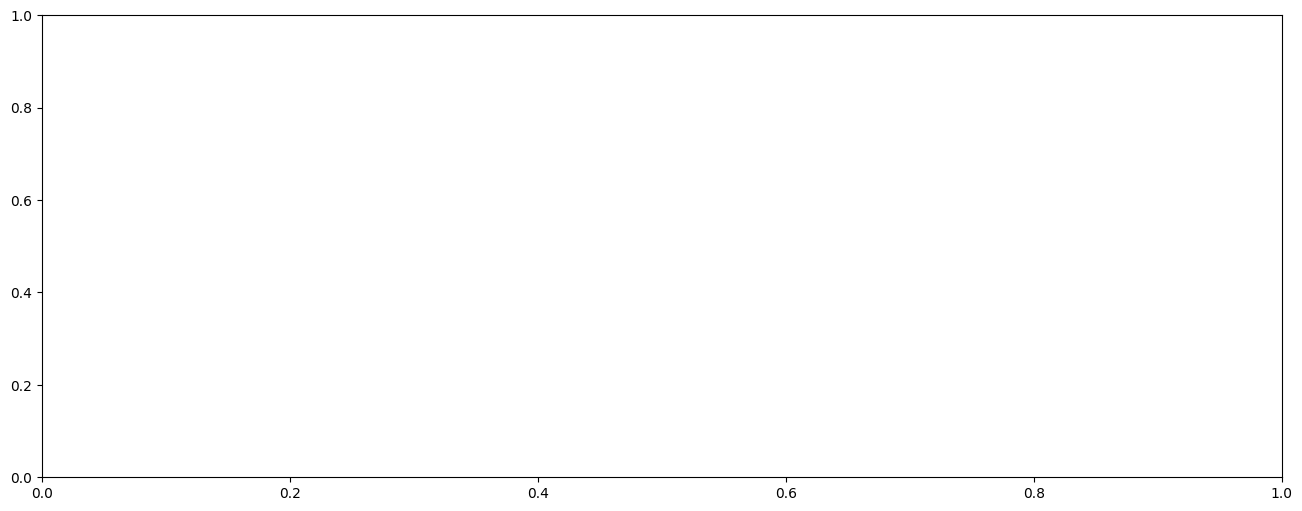

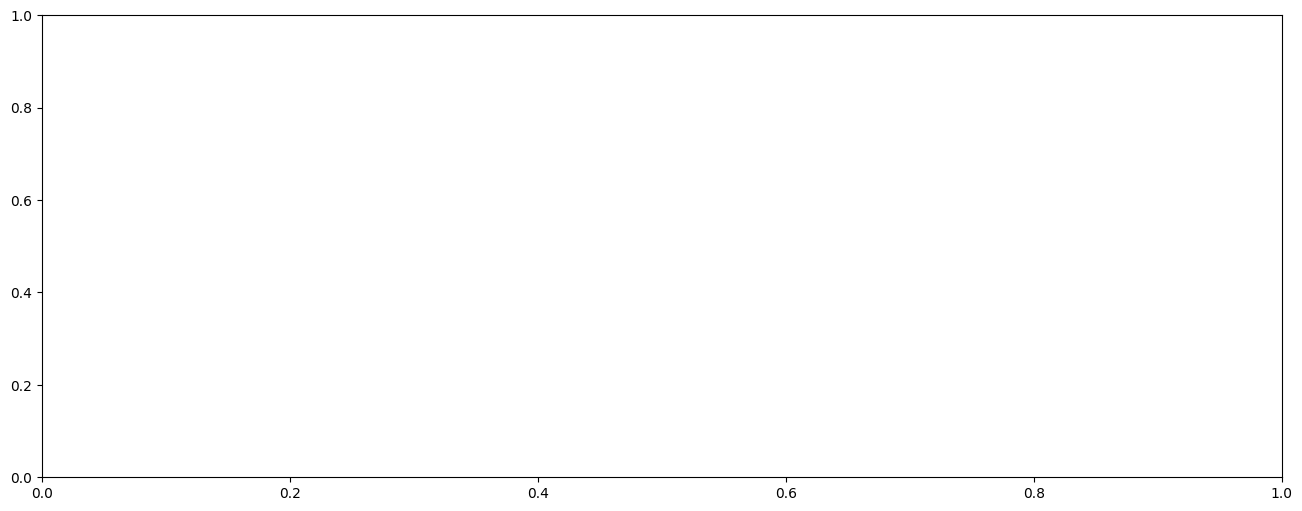

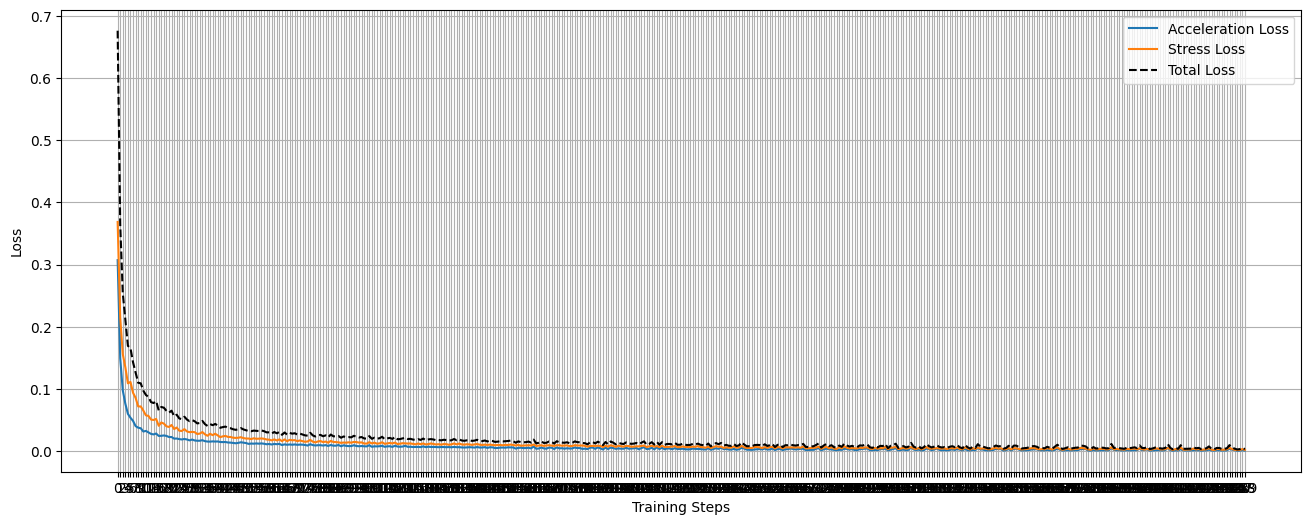

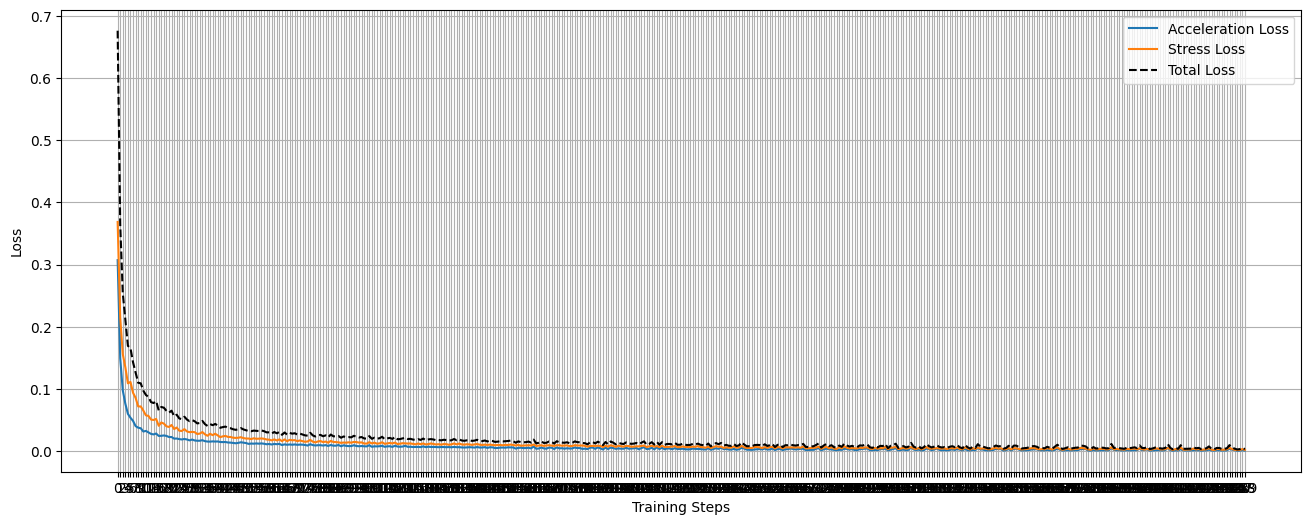

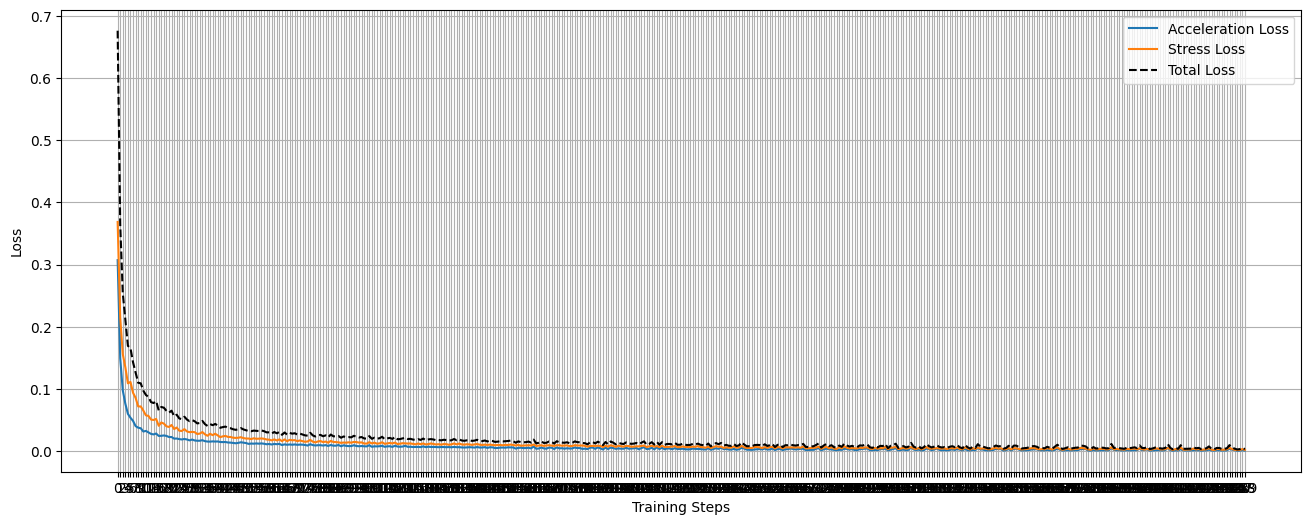

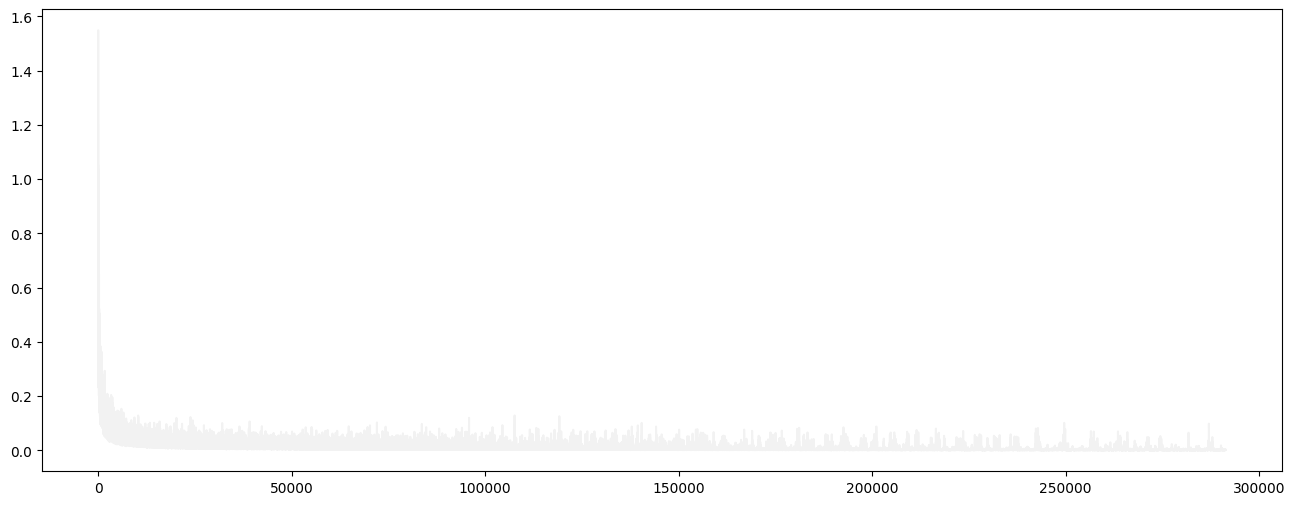

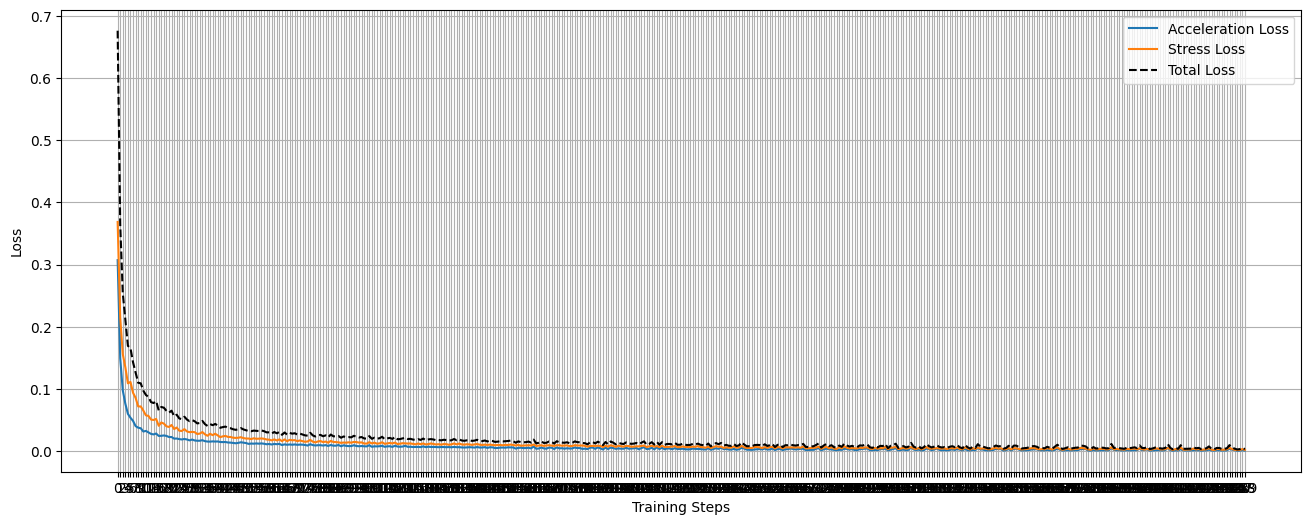

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

total_epochs = 440
len(train_dataloader)
epochs_indices = np.arange(
    0, total_epochs * len(train_dataloader), len(train_dataloader)
)
# print(epochs_indices)
plt.figure(figsize=(16, 6))
# plt.plot(trainer.train_history, label="Train loss", alpha=0.1, color="gray")
# plt.plot(epochs_indices, trainer.gen_test_history, label="Gen Test Loss")
acc_loss = np.array(trainer.train_acc_history).mean(axis=1)
stress_loss = np.array(trainer.train_stress_history).mean(axis=1)
plt.plot(epochs_indices, acc_loss, label="Acceleration Loss")
plt.plot(epochs_indices, stress_loss, label="Stress Loss")
total_loss = acc_loss + stress_loss
plt.plot(epochs_indices, total_loss, label="Total Loss", linestyle="--", color="black")
plt.legend()
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.xticks(epochs_indices, [str(i) for i in range(total_epochs)])
plt.grid()
plt.show()

### Show animation

In [18]:
from rollout_utils import do_rollout

model = trainer.model.eval()
no_rollout = False
true_rollout, pred_rollout = do_rollout(
    model=model,
    test_loader=test_dataloader,
    device=trainer.device,
    node_stats=node_stats,
    edge_stats=edge_stats,
    target_stats=target_stats,
    dt=dt,
    skip_first=0,
    rollout_steps=30,
    dont_rollout=no_rollout,
)

In [19]:
from make_gif import make_beam_comparison_gif


make_beam_comparison_gif(
    pred_rollout=pred_rollout,
    true_rollout=true_rollout,
    L=1.0,
    W=0.1,
    D=0.04,  # Beam dimensions
    out_gif="beam_comparison.gif",
    fps=4,
)

Rendering frame 0/30
Rendering frame 1/30
Rendering frame 2/30
Rendering frame 3/30
Rendering frame 4/30
Rendering frame 5/30
Rendering frame 6/30
Rendering frame 7/30
Rendering frame 8/30
Rendering frame 9/30
Rendering frame 10/30
Rendering frame 11/30
Rendering frame 12/30
Rendering frame 13/30
Rendering frame 14/30
Rendering frame 15/30
Rendering frame 16/30
Rendering frame 17/30
Rendering frame 18/30
Rendering frame 19/30
Rendering frame 20/30
Rendering frame 21/30
Rendering frame 22/30
Rendering frame 23/30
Rendering frame 24/30
Rendering frame 25/30
Rendering frame 26/30
Rendering frame 27/30
Rendering frame 28/30
Rendering frame 29/30
Rendering frame 30/30
GIF saved => beam_comparison.gif
Done.


In [ ]:
# from IPython.display import Image

# Image(filename="beam_comparison.gif")